# YouTube Channel Performance Prediction
## Exploratory Data Analysis & Model Development

This notebook explores the YouTube dataset, trains an XGBoost classifier, and provides SHAP interpretability analysis.

### 1. Setup & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set paths
data_dir = r'D:\L4S1\ML\Assignment\impl\Data'
outputs_dir = r'D:\L4S1\ML\Assignment\impl\outputs'
os.makedirs(outputs_dir, exist_ok=True)

# Load data
df = pd.read_csv(os.path.join(data_dir, 'processed_yt.csv'))
print('Dataset shape:', df.shape)
print('\nFirst few rows:')
print(df.head())

Dataset shape: (103663, 12)

First few rows:
                               time                channel_id  view_count  \
0  2025-07-31 02:08:06.933105+00:00  UCdJppX3uAMFMvCTuE9qCowg   102282758   
1  2025-07-31 02:08:06.933105+00:00  UC3UVENYr99HSHFi01lLMohg    61902338   
2  2025-07-31 02:08:06.933105+00:00  UCAwE7N-WJi9cqI0DfKOkKWw    33787179   
3  2025-07-31 02:08:06.933105+00:00  UCYFn7BOOlmL21iNJ6q5IDfg   553876631   
4  2025-07-31 02:08:06.933105+00:00  UC8Z-aOFJe-SmwXFRobzs0QA   118283986   

   subscriber_count  video_count  total_views  subscribers  years_active  \
0            854000          415    102282758       854000           3.0   
1            563000          283     61902338       563000           3.0   
2            386000           94     33787179       386000           3.0   
3           1860000          316    553876631      1860000           3.0   
4            500000          138    118283986       500000           3.0   

   engagement_proxy  activity_score

### 2. Exploratory Data Analysis

In [3]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

Missing values:
time                0
channel_id          0
view_count          0
subscriber_count    0
video_count         0
total_views         0
subscribers         0
years_active        0
engagement_proxy    0
activity_score      0
growth_rate         0
high_performing     0
dtype: int64

Data types:
time                    str
channel_id              str
view_count            int64
subscriber_count      int64
video_count           int64
total_views           int64
subscribers           int64
years_active        float64
engagement_proxy    float64
activity_score      float64
growth_rate         float64
high_performing       int64
dtype: object


Target distribution:
high_performing
0    0.749998
1    0.250002
Name: proportion, dtype: float64


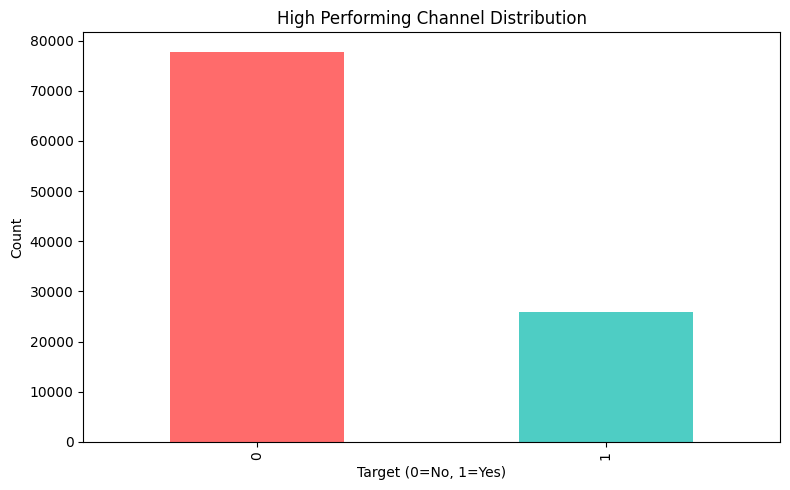

In [4]:
# Target distribution
print('Target distribution:')
print(df['high_performing'].value_counts(normalize=True))

plt.figure(figsize=(8, 5))
df['high_performing'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.title('High Performing Channel Distribution')
plt.xlabel('Target (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [5]:
# Summary statistics
print('Summary statistics:')
print(df.describe())

Summary statistics:
         view_count  subscriber_count    video_count   total_views  \
count  1.036630e+05      1.036630e+05  103663.000000  1.036630e+05   
mean   8.146358e+07      2.529296e+05    1743.943577  8.146358e+07   
std    3.862458e+08      7.343969e+05   13105.215202  3.862458e+08   
min    0.000000e+00      0.000000e+00       0.000000  0.000000e+00   
25%    1.558995e+05      3.140000e+03      32.000000  1.558995e+05   
50%    4.974986e+06      4.990000e+04     141.000000  4.974986e+06   
75%    3.309624e+07      1.960000e+05     524.000000  3.309624e+07   
max    1.665270e+10      4.480000e+07  318624.000000  1.665270e+10   

        subscribers  years_active  engagement_proxy  activity_score  \
count  1.036630e+05      103663.0     103663.000000   103663.000000   
mean   2.529296e+05           3.0        317.612227      581.314526   
std    7.343969e+05           0.0       2629.079887     4368.405067   
min    0.000000e+00           3.0          0.000000        0.0000

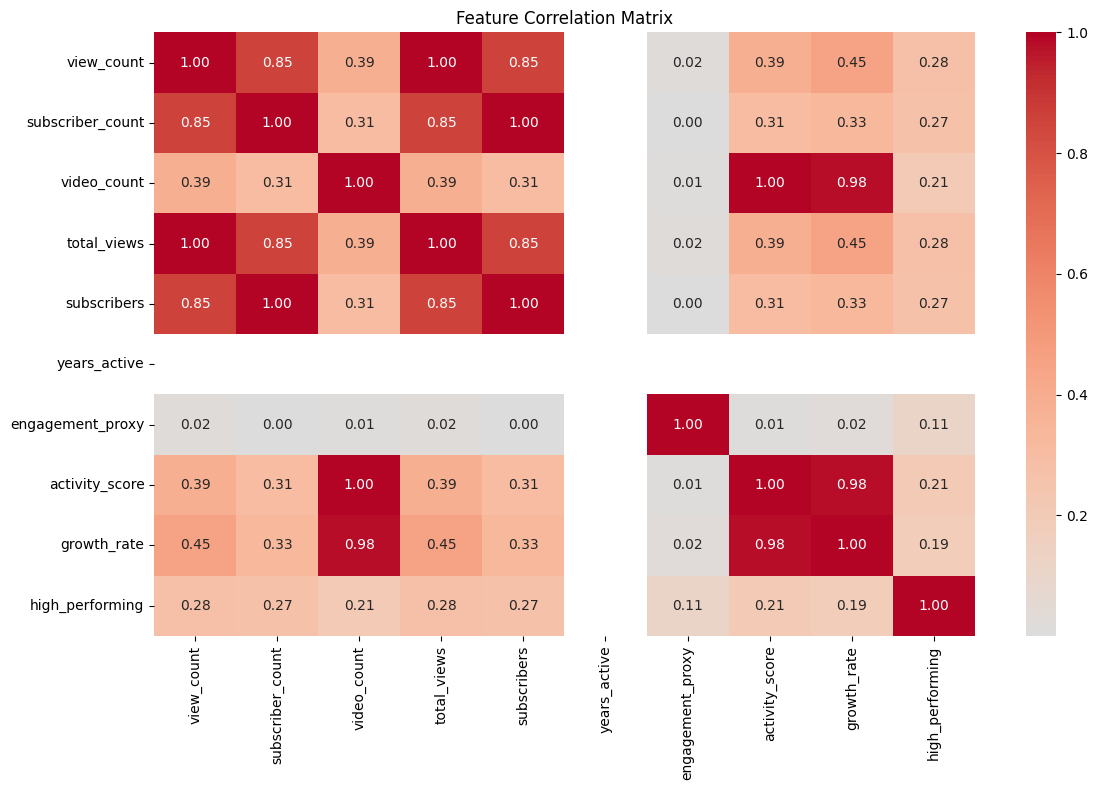

In [7]:
# Correlation analysis - numeric columns only
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### 3. Data Preparation & Model Training

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report

# Define features
num_features = ['view_count', 'subscriber_count', 'video_count', 'years_active', 
                'total_views', 'subscribers', 'growth_rate', 'engagement_proxy', 'activity_score']
cat_features = []

X = df[num_features]
y = df['high_performing']

print(f'Features: {len(num_features)}')
print(f'Samples: {len(X)}')
print(f'Target balance:', y.value_counts(normalize=True).to_dict())

Features: 9
Samples: 103663
Target balance: {0: 0.7499975883391374, 1: 0.2500024116608626}


In [9]:
# Split data
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

Train: 72605, Val: 15508, Test: 15550


In [10]:
# Build pipeline
preprocessor = ColumnTransformer([('num', StandardScaler(), num_features)])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        scale_pos_weight=sum(y_train==0)/sum(y_train==1),
        random_state=42,
        verbose=0
    ))
])

# Train
print('Training model...')
model.fit(X_train, y_train)
print('Training complete!')

Training model...
Training complete!


### 4. Model Evaluation

In [11]:
# Predictions
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

# Metrics
f1 = f1_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_proba)

print(f'Test F1 Score: {f1:.3f}')
print(f'Test AUC: {auc:.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_test_pred, target_names=['Not High-Performing', 'High-Performing']))

Test F1 Score: 0.999
Test AUC: 1.000

Classification Report:
                     precision    recall  f1-score   support

Not High-Performing       1.00      1.00      1.00     11662
    High-Performing       1.00      1.00      1.00      3888

           accuracy                           1.00     15550
          macro avg       1.00      1.00      1.00     15550
       weighted avg       1.00      1.00      1.00     15550



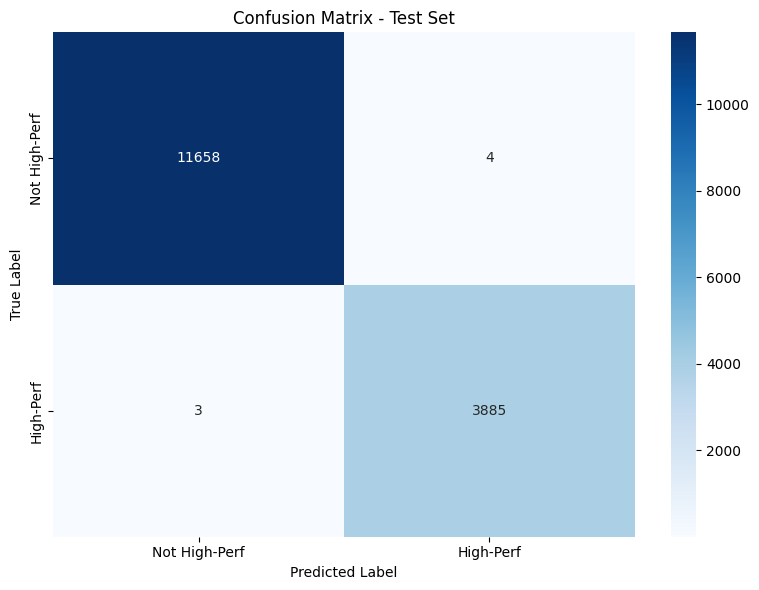

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not High-Perf', 'High-Perf'],
            yticklabels=['Not High-Perf', 'High-Perf'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, 'cm.png'), dpi=300, bbox_inches='tight')
plt.show()

### 5. Feature Importance

Feature Importances:
            feature  importance
6       growth_rate    0.997949
2       video_count    0.000686
7  engagement_proxy    0.000534
1  subscriber_count    0.000417
0        view_count    0.000413
4       total_views    0.000000
3      years_active    0.000000
5       subscribers    0.000000
8    activity_score    0.000000


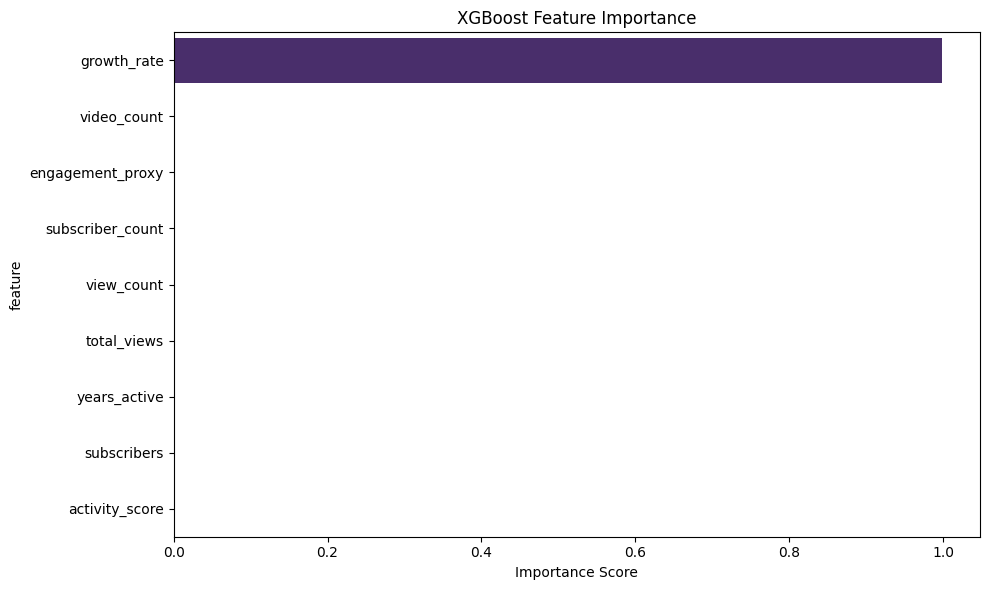

In [13]:
# XGBoost feature importance
feature_names = num_features
importances = model.named_steps['classifier'].feature_importances_
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print('Feature Importances:')
print(imp_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, 'features.png'), dpi=300, bbox_inches='tight')
plt.show()

### 6. SHAP Interpretability Analysis

In [14]:
import shap

print('Computing SHAP values...')

# Transform test data
X_test_trans = model.named_steps['preprocessor'].transform(X_test)
X_test_sample = X_test_trans[:100]  # Use first 100 samples for clarity

# Create explainer
explainer = shap.TreeExplainer(model.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_sample)

# Extract positive class SHAP values
if isinstance(shap_values, list):
    shap_pos = shap_values[1]
elif hasattr(shap_values, 'values'):
    shap_pos = shap_values.values if len(shap_values.values.shape) == 2 else shap_values.values[:, :, 1]
else:
    shap_pos = shap_values

# Ensure 2D
if len(shap_pos.shape) == 1:
    shap_pos = shap_pos.reshape(-1, 1)

print(f'SHAP values shape: {shap_pos.shape}')
print('SHAP computation complete!')

Computing SHAP values...
SHAP values shape: (100, 9)
SHAP computation complete!


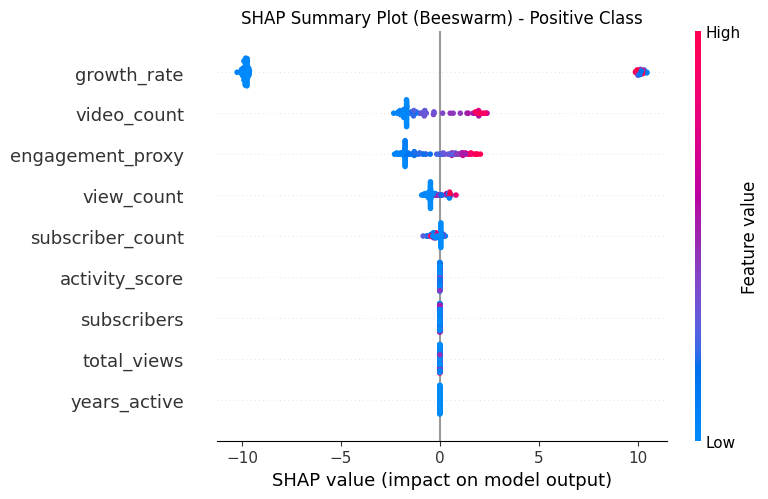

In [15]:
# SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_pos, X_test_sample, 
                  feature_names=feature_names, 
                  max_display=9, show=False)
plt.title('SHAP Summary Plot (Beeswarm) - Positive Class')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, 'shap_summary.png'), dpi=300, bbox_inches='tight')
plt.show()

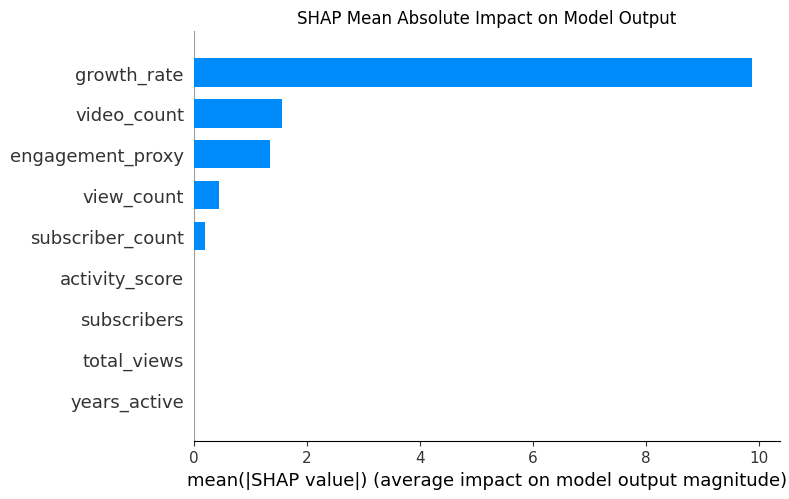

In [16]:
# SHAP bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_pos, X_test_sample, 
                  feature_names=feature_names, 
                  plot_type='bar', show=False, max_display=9)
plt.title('SHAP Mean Absolute Impact on Model Output')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, 'shap_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# SHAP force plot for individual samples
sample_idx = 0
shap.initjs()

# Handle expected_value - it might be scalar or array
expected_val = explainer.expected_value
if isinstance(expected_val, (list, tuple, np.ndarray)):
    expected_val = expected_val[1]

shap.force_plot(expected_val, shap_pos[sample_idx], 
                X_test_sample[sample_idx], feature_names=feature_names)

### 7. Model Summary

In [19]:
print('=' * 60)
print('MODEL SUMMARY')
print('=' * 60)
print(f'Dataset Size: {len(df)}')
print(f'Target Balance: {y.mean():.2%} High-Performing')
print(f'\nTest Performance:')
print(f'  F1 Score: {f1:.3f}')
print(f'  AUC-ROC: {auc:.3f}')
print(f'  Accuracy: {(y_test_pred == y_test).mean():.3f}')
print(f'\nTop 3 Important Features:')
for idx, row in imp_df.head(3).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")
print(f'\nOutputs saved to: {outputs_dir}')
print('=' * 60)

MODEL SUMMARY
Dataset Size: 103663
Target Balance: 25.00% High-Performing

Test Performance:
  F1 Score: 0.999
  AUC-ROC: 1.000
  Accuracy: 1.000

Top 3 Important Features:
  growth_rate: 0.9979
  video_count: 0.0007
  engagement_proxy: 0.0005

Outputs saved to: D:\L4S1\ML\Assignment\impl\outputs
